## Evolutionary Strategies
Evolutionary Strategies (ES) are a class of evolutionary algorithms first developed in the 1960s. They are noteable for their statistical recombination of the population to inform the next generation. ES are most often used for **continuous optimization** problems.

Some recent developments in ES include:

Daan Wierstra, Tom Schaul, Tobias Glasmachers, Yi Sun, Jan Peters, & Jürgen Schmidhuber (2014). Natural Evolution Strategies. Journal of Machine Learning Research, 15(27), 949–980. [pdf](https://jmlr.org/papers/volume15/wierstra14a/wierstra14a.pdf)

Tim Salimans, Jonathan Ho, Xi Chen, Szymon Sidor, and Ilya Sutskever. 2017. Evolution Strategies as a Scalable Alternative to Reinforcement Learning. [pdf](https://arxiv.org/abs/1703.03864)




In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import ticker, cm
import matplotlib.colors as colors
import numpy as np
import math

# A simple $(1 + 1)$ ES

The simplest Evolutionary Strategy is the $(1+1)$ ES. In this algorithm, the best individual generated is replaced by a new individual when its **fitness** is superior to the current best. For continuous optimization, we can use a representation of floating point numbers which are modified at each step using a Normal distribution:

    Initialize x randomly in ℝ
    while not terminate
        x' = x + 𝑁(0, σ)
        if f(x′) < f(x)
            x = x'
    return x

Evolutionary Strategies are commonly used for continuous optimization. We will use standard [test functions for continuous optimization](https://en.wikipedia.org/wiki/Test_functions_for_optimization), namely the Himmelblau and Rosenbrock functions. They are defined as follows:

Himmelblau: $f(x,y) = (x^2+y-11)^2 + (x+y^2-7)^2$

<!-- Rosenbrock: $f(x) = \sum_{i=1}^{n-1}(B(x_{i+1}-x_i^2)^2+(a-x_i)^2)$ -->
Rosenbrock: $f(x) = \sum_{i=1}^{n-1}(B(x_{i+1}-x_i^2)^2+(a-x_i)^2)$

In [2]:
def himmelblau(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

In [3]:
def rosenbrock(x, y, a=1, B=100):
      return B*((y-x**2))**2 + (a-x)**2

We can visualize these functions for a better understanding of the search space.

In [4]:
X = np.arange(-5, 5, 0.1)
Y = np.arange(-5, 5, 0.1)
X, Y = np.meshgrid(X, Y)
Z = himmelblau(X, Y)
# Z = rosenbrock(X, Y)

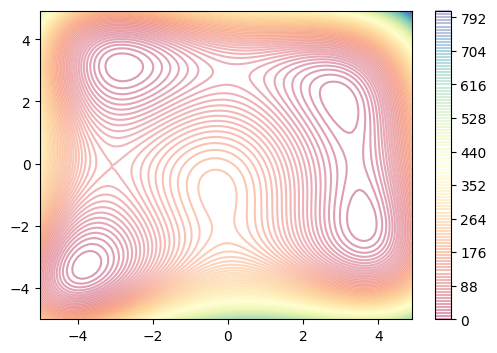

In [5]:
fig = plt.figure(figsize=(6, 4))
cs = plt.contour(X, Y, Z, levels=100, cmap='Spectral',
                 norm=colors.Normalize(vmin=Z.min(), vmax=Z.max()), alpha=0.4)
fig.colorbar(cs)
plt.show()

For the (1+1) ES, we start with a random point $x$ and then sample one point around it using a Normal distribution.|

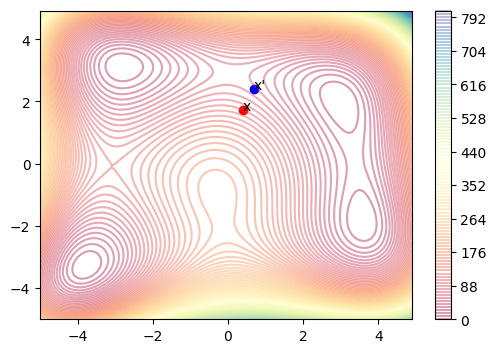

In [6]:
np.random.seed(0)
x = np.random.rand(2) * 8 - 4
x_orig = np.copy(x)
#print("position: ", x, "fitness :", himmelblau(x[0], x[1]))
σ = 0.3
x_t = np.random.randn(2)*σ + x
#print("new position: ", x_t, "new fitness :", himmelblau(x_t[0], x_t[1]))
fig = plt.figure(figsize=(6, 4))
cs = plt.contour(X, Y, Z, levels=100, cmap='Spectral', norm=colors.Normalize(vmin=Z.min(), vmax=Z.max()), alpha=0.4)
plt.annotate('x\'', (x_t))
plt.scatter(x_t[0], x_t[1], c='b')
plt.annotate('x', (x))
plt.scatter(x[0], x[1], c='r')
fig.colorbar(cs);

# The $(1 + \lambda)$ ES
While the $(1 + 1)$ ES algorithm could allow us to move around the search space and eventually find an optimum, we can use multiple samples of this distribution to better inform the movement in the search space. We therefore instead sample multiple points following a Normal distribution around $x$:

In [7]:
x = np.copy(x_orig)
#print("position: ", x, "fitness :", himmelblau(x[0], x[1]))
x_t = np.array([x + np.random.normal(size=(2,))*σ for i in range(20)])
x_best = x
fit_best = himmelblau(x[0], x[1])
for i in range(20):
    f = himmelblau(x_t[i, 0], x_t[i, 1])
    if f < fit_best:
        fit_best = f
        x_best = x_t[i, 0], x_t[i, 1]
#print("best position: ", x_best, "best fitness :", fit_best)

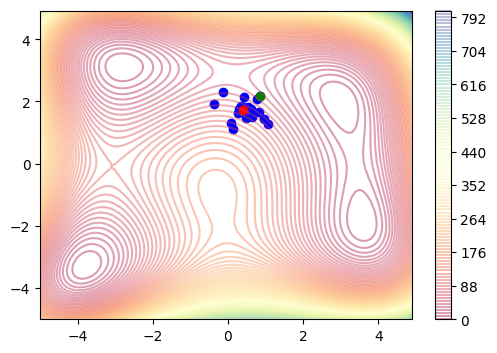

In [8]:
fig = plt.figure(figsize=(6, 4))
cs = plt.contour(X, Y, Z, levels=100, cmap='Spectral', norm=colors.Normalize(vmin=Z.min(), vmax=Z.max()), alpha=0.4)
plt.scatter(x_t[:, 0], x_t[:, 1], c='b')
plt.scatter(x[0], x[1], c='r')
plt.scatter(x_best[0], x_best[1], c='g')
fig.colorbar(cs);

Having this population of points will enable us to explore the space around $x$ before moving on to the next step. However, these points might overlap or cover spaces that have already been explored. Generating too many points could slow down search, requiring more evaluations of the objective function. In many applications, that is costly.

Performing random optimization but sampling more than 1 point leads to the $(1+\lambda)$ Evolutionary Strategy.

    Initialize x randomly in ℝ
    x_best = x
    while not terminate
        for i in [1,λ]
            x_i = x + 𝑁(0, σ)
            if f(x_i) < f(x_best)
                x_best = x_i
        x = x_best
    return x_best

In the scope of evolutionary algorithms, we'll refer to $x$ as a parent and all $x'$ points as offspring. Each point can also be referred to as an individual in a population, and $f(x)$ is called the fitness of the individual. Each iteration of the algorithm is called a generation.

<div class="alert alert-info">

The $(\mu/\rho,\lambda)$ or $(\mu/\rho+\lambda)$ notation signifies the configuration of parents and offspring. In this notation, $\mu$ is the number of parents, $\rho$ is the number of parents involved in creating the offspring, and $\lambda$ is the number of offspring. $(\mu/\rho+\lambda)$ means the parents can be included in the next population, whereas $(\mu/\rho,\lambda)$ means the parents are not included. $(1+\lambda)$ therefore means that 1 parent is involved in creating a population of $\lambda$ offspring and can be included in the next generation (ie, if $f(x) < f(x') \forall x'$, $x$ does not change).
    
</div>

In [9]:
def oneplus_lambda(x, fitness, gens=100, lam=20):
    x_best = x
    f_best = fitness(x)
    fits = np.zeros(gens)
    for g in range(gens):
        N = np.random.normal(size=(lam, len(x)))
        for i in range(lam):
            ind = x + N[i, :]
            f = fitness(ind)
            if f < f_best:
                f_best = f
                x_best = ind
        x = x_best
        fits[g] = f_best
    return fits

Let's run the $(1+\lambda)$ ES on the himmelblau function over 5 repeats.

In [10]:
f = lambda x : himmelblau(x[0], x[1])
reps = []
for i in range(5):
    x = np.random.rand(2)*10-5
    reps += [oneplus_lambda(x, f)]
reps = np.array(reps)
reps_mean = np.mean(reps, 0)
reps_std = np.std(reps, 0)

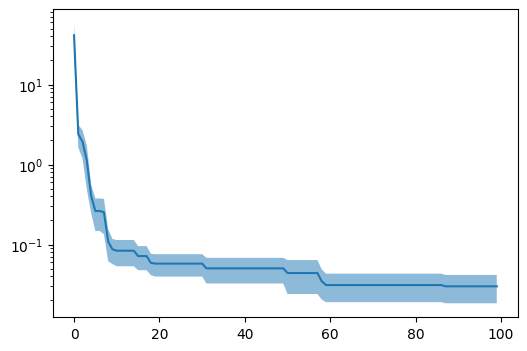

In [11]:
fig = plt.figure(figsize=(6, 4))
plt.fill_between(range(len(reps[0])), reps_mean+0.5*reps_std, reps_mean-0.5*reps_std, alpha=0.5)
plt.plot(range(len(reps[0])), reps_mean)
plt.yscale('log')

<div class="alert alert-success">
    <h3>Exercise 1</h3>
    Study the impact of the $\lambda$ parameter by modifying it and re-running the optimization. What is the best $\lambda$ value for the Himmelblau problem?
</div>

In [12]:
f = lambda x : himmelblau(x[0], x[1])
l = 20
reps = []
for i in range(5):
    x = np.random.rand(2)*10-5
    reps += [oneplus_lambda(x, f, lam = l)]
reps = np.array(reps)
reps_mean = np.mean(reps, 0)
reps_std = np.std(reps, 0)

evals = np.arange(len(reps[0]))*l

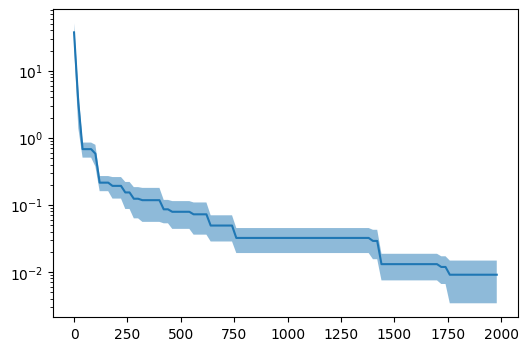

In [13]:
fig = plt.figure(figsize=(6, 4))
plt.fill_between(evals, reps_mean+0.5*reps_std, reps_mean-0.5*reps_std, alpha=0.5)
plt.plot(evals, reps_mean)
plt.yscale('log')

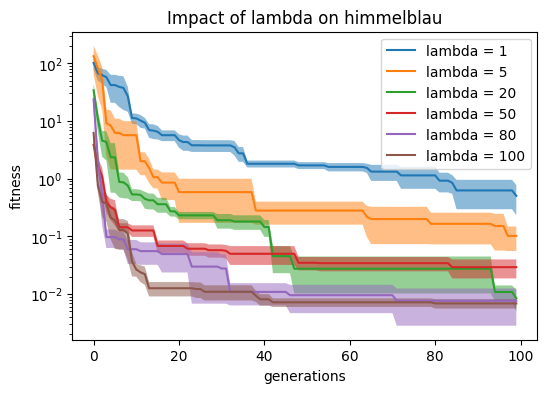

In [14]:
f = lambda x : himmelblau(x[0], x[1])
lambdas = [1, 5, 20, 50, 80, 100]

figs, ax = plt.subplots(figsize=(6, 4))

for l in lambdas:
    reps_l = []
    for i in range(5):
        x = np.random.rand(2)*10-5
        reps_l += [oneplus_lambda(x, f, lam = l)]
    reps_l = np.array(reps_l)
    reps_mean = np.mean(reps_l, 0)
    reps_std = np.std(reps_l, 0)

    ax.fill_between(range(len(reps_l[0])), reps_mean+0.5*reps_std, reps_mean-0.5*reps_std, alpha=0.5)
    ax.plot(range(len(reps_l[0])), reps_mean, label=f"lambda = {l}")

ax.set_yscale('log')
ax.set_xlabel('generations')
ax.set_ylabel('fitness')
ax.set_title('Impact of lambda on himmelblau')
ax.legend()

Higher lambdas explore the search space more, so they may appear to perform better, but we need to consider the cost. They use more evaluations per generation, so we should compare performance per evaluation, not per generation.

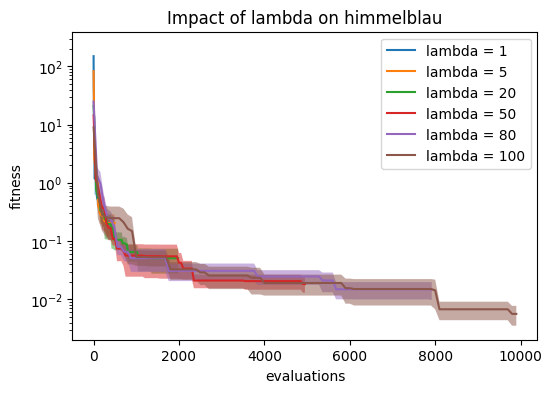

In [15]:
lf = lambda x : himmelblau(x[0], x[1])

figs, ax = plt.subplots(figsize=(6, 4))

for l in lambdas:
    reps_l = []
    for i in range(5):
        x = np.random.rand(2)*10-5
        reps_l += [oneplus_lambda(x, f, lam = l)]
    reps_l = np.array(reps_l)
    reps_mean = np.mean(reps_l, 0)
    reps_std = np.std(reps_l, 0)

    evals = np.arange(len(reps_l[0]))*l
    ax.fill_between(evals, reps_mean+0.5*reps_std, reps_mean-0.5*reps_std, alpha=0.5)
    ax.plot(evals, reps_mean, label=f"lambda = {l}")

ax.set_yscale('log')
ax.set_xlabel('evaluations')
ax.set_ylabel('fitness')
ax.set_title('Impact of lambda on himmelblau')
ax.legend()

Based on the curves over evaluations, we can see that the drastic performance differences between different lambda values are gone. A relatively small lambda, such as 20 can perform reasonably well, especially when considering the evaluation costs.

<div class="alert alert-success">
    <h3>Exercise 2</h3>
    Change to the Rosenbrock problem. What is the difficulty of this search space, compared to Himmelblau? Can you find a $\lambda$ parameter adapted to this search space?
</div>

In [16]:
X = np.arange(-5, 5, 0.1)
Y = np.arange(-5, 5, 0.1)
X, Y = np.meshgrid(X, Y)
Z = rosenbrock(X, Y)

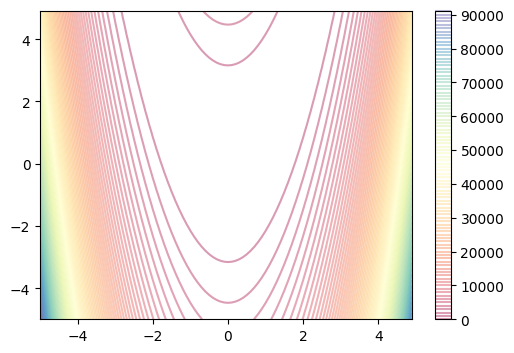

In [17]:
fig = plt.figure(figsize=(6, 4))
cs = plt.contour(X, Y, Z, levels=100, cmap='Spectral',
                 norm=colors.Normalize(vmin=Z.min(), vmax=Z.max()), alpha=0.4)
fig.colorbar(cs)
plt.show()

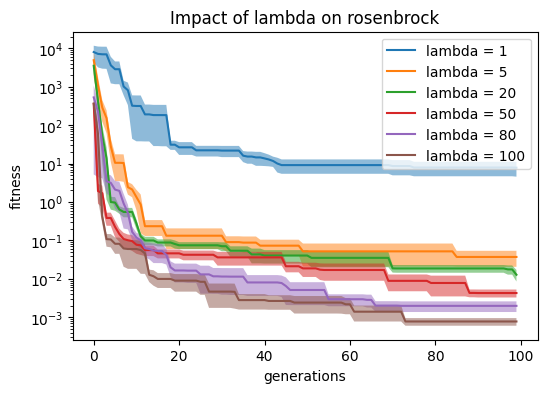

In [18]:
f = lambda x : rosenbrock(x[0], x[1])

figs, ax = plt.subplots(figsize=(6, 4))

for l in lambdas:
    reps_l = []
    for i in range(5):
        x = np.random.rand(2)*10-5
        reps_l += [oneplus_lambda(x, f, lam = l)]
    reps_l = np.array(reps_l)
    reps_mean = np.mean(reps_l, 0)
    reps_std = np.std(reps_l, 0)

    ax.fill_between(range(len(reps_l[0])), reps_mean+0.5*reps_std, reps_mean-0.5*reps_std, alpha=0.5)
    ax.plot(range(len(reps_l[0])), reps_mean, label=f"lambda = {l}")

ax.set_yscale('log')
ax.set_xlabel('generations')
ax.set_ylabel('fitness')
ax.set_title('Impact of lambda on rosenbrock')
ax.legend()

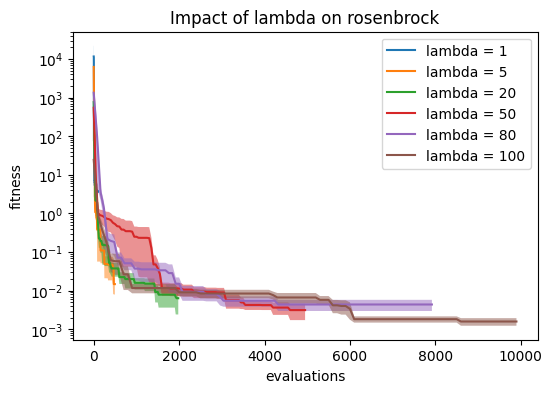

In [19]:
f = lambda x : rosenbrock(x[0], x[1])

figs, ax = plt.subplots(figsize=(6, 4))

for l in lambdas:
    reps_l = []
    for i in range(5):
        x = np.random.rand(2)*10-5
        reps_l += [oneplus_lambda(x, f, lam = l)]
    reps_l = np.array(reps_l)
    reps_mean = np.mean(reps_l, 0)
    reps_std = np.std(reps_l, 0)

    evals = np.arange(len(reps_l[0]))*l
    ax.fill_between(evals, reps_mean+0.5*reps_std, reps_mean-0.5*reps_std, alpha=0.5)
    ax.plot(evals, reps_mean, label=f"lambda = {l}")

ax.set_yscale('log')
ax.set_xlabel('evaluations')
ax.set_ylabel('fitness')
ax.set_title('Impact of lambda on rosenbrock')
ax.legend()

The Rosenbrock function looks more complex and we can see the curves start at worse fitness values as the ES struggles more. My initial thought was that larger lambda values may not necessarily help on Rosenbrock. Himmelblau’s function has four global minima, so it can benefit from larger but moderate lambda, since more offspring can explore the search space and discover different minimas. We want moderate step sizes, since larger lambdas require more evaluations and do not necessarily improve performance enough to justify their cost. Rosenbrock has only one global minimum, but its curvature is very different in different directions, so the step size is crucial and small steps cause very slow convergence along the flat direction, but large steps on the other hand can overshoot along the steep direction. So, based on the plot, we need a population larger than 1 and larger lambdas do perform better. However, considering the cost, even lambda values around 20 or 50 already work well.

In [20]:
X = np.arange(-5, 5, 0.1)
Y = np.arange(-5, 5, 0.1)
X, Y = np.meshgrid(X, Y)
Z = himmelblau(X, Y) # Back to Himmelblau

# Approximating the gradient

In the $(1+\lambda)$ ES, we move from the best point in a population to the best point in the next randomly sampled population. However, with the population information, we can do better than that; we can move in the direction of the gradient approximated by the fitness values of the population. This makes better use of the full population information by combining all fitness information instead of selecting the best fitness value.

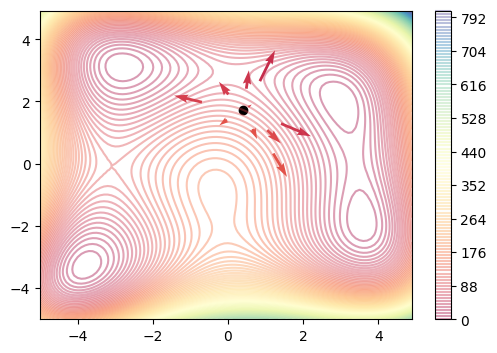

In [21]:
x = np.copy(x_orig)
x_t = np.array([x + np.random.normal(size=(2,))*0.5 for i in range(10)])
fits = himmelblau(x_t[:, 0], x_t[:, 1])
fig = plt.figure(figsize=(6, 4))
norm = colors.Normalize(vmin=Z.min(), vmax=Z.max())
cs = plt.contour(X, Y, Z, levels=100, cmap='Spectral', alpha=0.4, norm=norm)
plt.quiver(x_t[:, 0], x_t[:, 1], x_t[:, 0]-x[0], x_t[:, 1]-x[1],
           fits, scale=fits/60, scale_units='xy', cmap='Spectral', norm=norm)
plt.scatter(x[0], x[1], c='k')
fig.colorbar(cs)
plt.show()

Instead of directly using the fitness values $f$, we will normalize all fitness values by the average $\mu(f(x))$ and standard deviation $\sigma(f(x))$ of the population.

$A = \frac{f(x) - \mu(f(x))}{\sigma(f(x))}$

We'll then define a vector at each point, $x_i - x$.

$N_i = x_i - x$

We multiply $A$ by all individual vectors which scales the vector magnitude by the relative fitness. Finally, we sum all vectors and divide by $\lambda$ to get the weighted average.

$\frac{1}{\lambda}\sum_i A_i N_i$

This is equivalent to the dot product and is used as our gradient approximation. Since we're minimizing, we'll use the negative value to do gradient descent.

$\nabla f \approx -\frac{A \cdot N}{\lambda}$

In [22]:
λ = 10
A = (fits - np.mean(fits)) / np.std(fits)
N = x_t - x
G = -np.dot(A, N) / λ

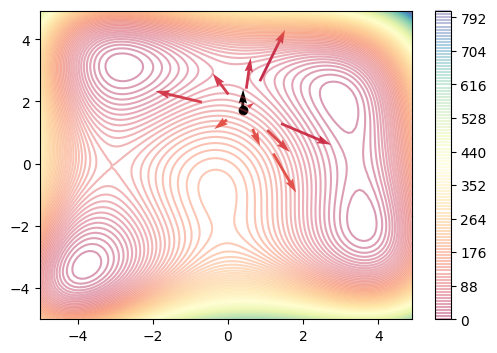

In [23]:
fig = plt.figure(figsize=(6, 4))
norm = colors.Normalize(vmin=Z.min(), vmax=Z.max())
cs = plt.contour(X, Y, Z, levels=100, cmap='Spectral', alpha=0.4, norm=norm)
plt.quiver(x_t[:, 0], x_t[:, 1], x_t[:, 0]-x[0], x_t[:, 1]-x[1],
           fits, scale=fits/100, scale_units='xy', cmap='Spectral', norm=norm)
plt.quiver(x[0], x[1], G[0], G[1])
plt.scatter(x[0], x[1], c='k')
fig.colorbar(cs)
plt.show()

We have our approximate gradient direction, but how far should we move in it? We'll define a learning rate variable $\alpha$ as the fixed magnitude of movement for now, so our update of $x$ is then

$x = x - \alpha\frac{A \cdot N}{\lambda}$

Let's put this all together as an Evolutionary Strategy. It is a $(\mu, \lambda)$ ES as multiple individuals $\mu$ inform the next generation; however, these individuals are not kept for the next generation.

    Initialize x randomly in ℝ
    while not terminate
        for i in [1,λ]
            N_i = 𝑁(0, 1)
            F_i = f(x + N_i)
        A = (F−𝜇(F))/𝜎(F)
        x = x - 𝛼(A⋅N)/𝜆

In [24]:
def mu_lambda(x, fitness, gens=200, lam=10, alpha=0.2, verbose=False):
    x_best = x
    f_best = fitness(x)
    fits = np.zeros(gens)
    for g in range(gens):
        N = np.random.normal(size=(lam, len(x)))
        F = np.zeros(lam)
        for i in range(lam):
            ind = x + N[i, :]
            F[i] = fitness(ind)
            if F[i] < f_best:
                f_best = F[i]
                x_best = ind
                if verbose:
                    print(g, " ", f_best)
        fits[g] = f_best
        mu_f = np.mean(F)
        std_f = np.std(F)
        A = F
        if std_f != 0:
            A = (F - mu_f) / std_f
        x = x - alpha * np.dot(A, N) / lam
    return fits, x_best

In [25]:
reps = []
for i in range(5):
    x = np.random.randn(2)
    fits, _ = mu_lambda(x, f)
    reps += [fits]
reps = np.array(reps)
reps_mean = np.mean(reps, 0)
reps_std = np.std(reps, 0)

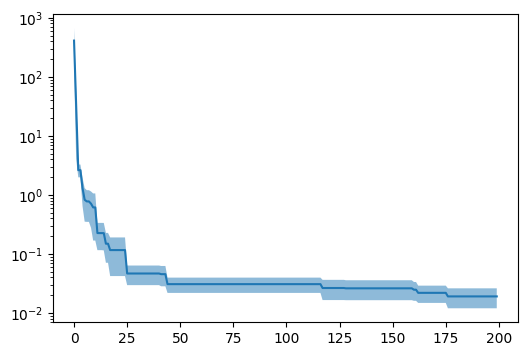

In [26]:
fig = plt.figure(figsize=(6, 4))
plt.fill_between(range(len(reps[0])), reps_mean+0.5*reps_std, reps_mean-0.5*reps_std, alpha=0.5)
plt.plot(range(len(reps[0])), reps_mean)
plt.yscale('log')

<div class="alert alert-success">
    <h3>Exercise 3</h3>
    
Study the impact of the $\alpha$ parameter by modifying it and re-running the optimization. Compare the best parameters found with the results from the $(1+\lambda)$ ES.
</div>

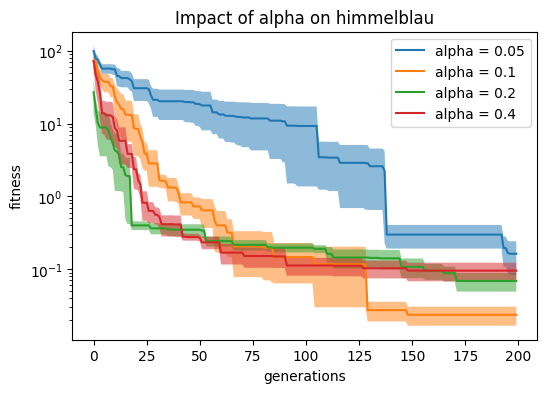

In [27]:
f = lambda x : himmelblau(x[0], x[1])
alphas = [0.05, 0.1, 0.2, 0.4]

figs, ax = plt.subplots(figsize=(6, 4))

for a in alphas:
    reps_a = []
    for i in range(5):
        x = np.random.randn(2)
        fits, _ = mu_lambda(x, f, alpha=a)
        reps_a += [fits]
    reps_a = np.array(reps_a)
    reps_mean_a = np.mean(reps_a, 0)
    reps_std_a = np.std(reps_a, 0)

    ax.fill_between(range(len(reps_a[0])), reps_mean_a+0.5*reps_std_a, reps_mean_a-0.5*reps_std_a, alpha=0.5)
    ax.plot(range(len(reps_a[0])), reps_mean_a, label=f"alpha = {a}")

ax.set_yscale('log')
ax.set_xlabel('generations')
ax.set_ylabel('fitness')
ax.set_title('Impact of alpha on himmelblau')
ax.legend()

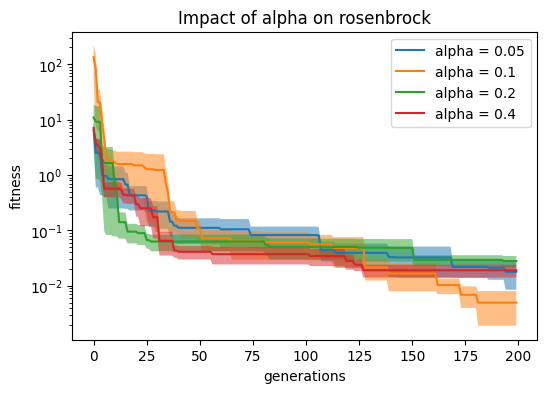

In [28]:
f = lambda x : rosenbrock(x[0], x[1])

figs, ax = plt.subplots(figsize=(6, 4))

for a in alphas:
    reps_a = []
    for i in range(5):
        x = np.random.randn(2)
        fits, _ = mu_lambda(x, f, alpha=a)
        reps_a += [fits]
    reps_a = np.array(reps_a)
    reps_mean_a = np.mean(reps_a, 0)
    reps_std_a = np.std(reps_a, 0)

    ax.fill_between(range(len(reps_a[0])), reps_mean_a+0.5*reps_std_a, reps_mean_a-0.5*reps_std_a, alpha=0.5)
    ax.plot(range(len(reps_a[0])), reps_mean_a, label=f"alpha = {a}")

ax.set_yscale('log')
ax.set_xlabel('generations')
ax.set_ylabel('fitness')
ax.set_title('Impact of alpha on rosenbrock')
ax.legend()

There is a trade-off with alpha, as smaller alphas lead to more stable but slower progress, as can be seen in the himmelblau plot for alpha = 0.05 lies above all the other higher alpha curves. As we increase alpha the steps become larger, giving faster convergence while the update is less careful and can overshoot the optimum. So a moderate alpha can be seen as around the ones I picked to plot, from about 0.1 to 0.4, with 0.1 achieving very good fitness with 200 generations in our experiment.

<div class="alert alert-success">
    <h3>Exercise 4</h3>
    
Study the performance of the $(\mu, \lambda)$ ES on the Rastrigin function. Does it perform better or worse than the  $(1+\lambda)$ ES?
</div>

In [29]:
def rastrigin(x, y):
    return (10*2 + (x**2 - 10*math.cos(2*math.pi*x)) + (y**2 - 10*math.cos(2*math.pi*y)))

In [30]:
f = lambda x : rastrigin(x[0], x[1])
reps_one_lambda = []
for i in range(5):
    x = np.random.rand(2)*10-5
    reps_one_lambda += [oneplus_lambda(x, f, 200)]
reps_one_lambda = np.array(reps_one_lambda)
reps_mean_one_lambda = np.mean(reps_one_lambda, 0)
reps_std_one_lambda = np.std(reps_one_lambda, 0)

In [31]:
f = lambda x : rastrigin(x[0], x[1])
reps_mu_lambda = []
for i in range(5):
    x = np.random.rand(2)*10-5
    fits_mu_lambda, _ = mu_lambda(x, f)
    reps_mu_lambda += [fits_mu_lambda]
reps_mu_lambda = np.array(reps_mu_lambda)
reps_mean_mu_lambda = np.mean(reps_mu_lambda, 0)
reps_std_mu_lambda = np.std(reps_mu_lambda, 0)

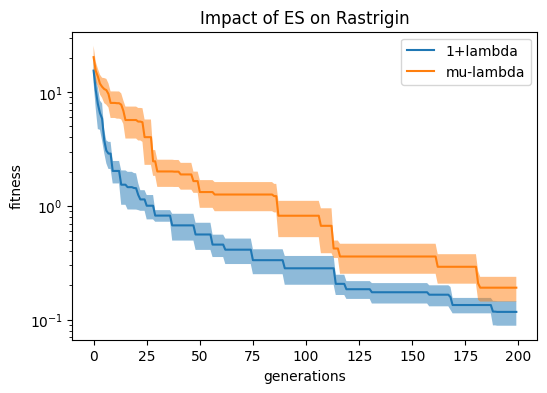

In [32]:
fig = plt.figure(figsize=(6, 4))
plt.fill_between(range(len(reps_one_lambda[0])), reps_mean_one_lambda+0.5*reps_std_one_lambda, reps_mean_one_lambda-0.5*reps_std_one_lambda, alpha=0.5)
plt.plot(range(len(reps_one_lambda[0])), reps_mean_one_lambda, label="1+lambda")

plt.fill_between(range(len(reps_mu_lambda[0])), reps_mean_mu_lambda+0.5*reps_std_mu_lambda, reps_mean_mu_lambda-0.5*reps_std_mu_lambda, alpha=0.5)
plt.plot(range(len(reps_mu_lambda[0])), reps_mean_mu_lambda, label="mu-lambda")

plt.xlabel('generations')
plt.ylabel('fitness')
plt.yscale('log')
plt.title('Impact of ES on Rastrigin')
plt.legend()

Both 1+lambda and mu,lambda perform relatively similarly. Over the generatios, we see that 1+lambda performs slightly better. The 1+lambda ES keeps the best point, whereas the mu,lambda ES uses a gradient-like update that can sometimes move away from good solutions. Tuning the parameters alpha and lambda could change these results to some extent.

# Rank-based update

We can make two observations about our current $(\mu, \lambda)$ Evolutionary Strategy:

1. Not all $\lambda$ points may be useful for the centroid update
2. Exact gradient information may be noisier than relative *rank* of individual fitness

Let's illustrate this point in the Himmelblau function. Instead of using all $\lambda$ points, we'll use a smaller value of $\mu$, for example $\frac{1}{2}\lambda$. We'll also create a list of weights which exponentially decreases from the first to last weight.

In [33]:
mu = 5
w = np.log(mu + 1/2) - np.log(np.arange(1, mu+1))
w /= np.sum(w)
w

array([0.45627265, 0.2707531 , 0.16223112, 0.08523355, 0.02550959])

As before, we create a random starting point and then add Gaussian noise to create offspring.

In [34]:
x = np.copy(x_orig)
N = np.random.normal(size=(10,2))*0.5
x_t = x + N
fits = himmelblau(x_t[:, 0], x_t[:, 1])
fits

array([133.1660362 , 122.16885514,  93.77732381,  93.13876258,
        77.93508469,  75.71243209,  86.50929357, 122.09026379,
       120.89298921,  97.46899009])

Now, however, instead of directly using fitness values, we'll select the best individuals and update using their weighted values.

In [35]:
sorted_ids = np.argsort(fits)
weighted = N[sorted_ids[:mu]] * w.reshape(mu, 1)
weighted

array([[ 0.31114465, -0.01061942],
       [ 0.04072995,  0.10524551],
       [-0.18587821,  0.04053778],
       [ 0.02519241, -0.00895998],
       [-0.01141698,  0.00504663]])

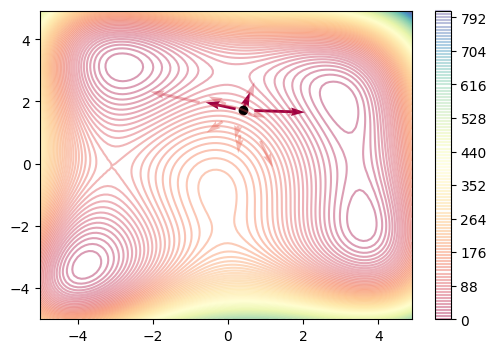

In [36]:
fig = plt.figure(figsize=(6, 4))
norm = colors.Normalize(vmin=Z.min(), vmax=Z.max())
cs = plt.contour(X, Y, Z, levels=100, cmap='Spectral', alpha=0.4, norm=norm)
plt.quiver(x_t[:, 0], x_t[:, 1], x_t[:, 0]-x[0], x_t[:, 1]-x[1],
           fits, scale=fits/100, scale_units='xy', cmap='Spectral', norm=norm, alpha=0.4)
plt.quiver(x[0]+weighted[:, 0], x[1]+weighted[:, 1], weighted[:, 0], weighted[:, 1],
           w, scale_units='xy', cmap='Spectral', norm=norm)
plt.scatter(x[0], x[1], c='k')
fig.colorbar(cs)
plt.show()

The first point is clear: using all points in the centroid update could pull it away from nearby optima. The second point is a bit harder to understand, but motivation is this: any transformation to the search space which **preserves rank** for the top $\mu$ individuals does not change the update. This invariance property is helpful to search because it increases the predictive power of the fitness by inducing problem equivalence classes.

Hansen, N., Ros, R., Mauny, N., Schoenauer, M., & Auger, A. (2011). Impacts of invariance in search: When CMA-ES and PSO face ill-conditioned and non-separable problems. Applied Soft Computing, 11(8), 5755-5769.

Incorporating these two changes to the previous $(\mu, \lambda)$ ES brings us an ES referred to as Canonical ES:

<img src="https://github.com/d9w/evolution/raw/master/imgs/canonical.png" width="40%" height="auto">

Chrabaszcz, P., Loshchilov, I., & Hutter, F. (2018, July). Back to basics: benchmarking canonical evolution strategies for playing Atari. In Proceedings of the 27th International Joint Conference on Artificial Intelligence (pp. 1419-1426). [code](https://github.com/PatrykChrabaszcz/Canonical_ES_Atari)

<img src="https://github.com/d9w/evolution/raw/master/imgs/canonical_results.png" width="80%" height="auto">

<div class="alert alert-success">
    <h3>Exercise 5</h3>
    
Consider the Rosenbrock function. How do you expect the gradient rankings to compare to the gradient information? Will they be very similar or different? Plot a sample to investigate.
</div>

# Gradient Information

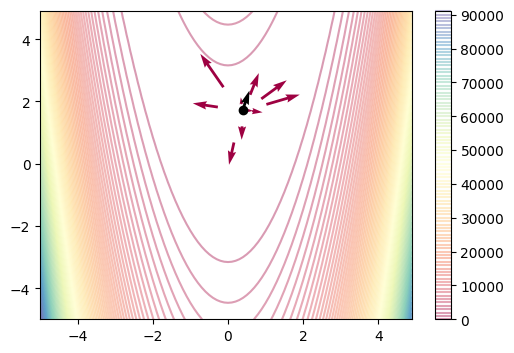

In [73]:
X = np.arange(-5, 5, 0.1)
Y = np.arange(-5, 5, 0.1)
X, Y = np.meshgrid(X, Y)
Z = rosenbrock(X, Y)

λ = 10
A = (fits - np.mean(fits)) / np.std(fits)
N = x_t - x
G = -np.dot(A, N) / λ

fig = plt.figure(figsize=(6, 4))
norm = colors.Normalize(vmin=Z.min(), vmax=Z.max())
cs = plt.contour(X, Y, Z, levels=100, cmap='Spectral', alpha=0.4, norm=norm)
plt.quiver(x_t[:, 0], x_t[:, 1], x_t[:, 0]-x[0], x_t[:, 1]-x[1],
           fits, scale=fits/100, scale_units='xy', cmap='Spectral', norm=norm)
plt.quiver(x[0], x[1], G[0], G[1])
plt.scatter(x[0], x[1], c='k')
fig.colorbar(cs)
plt.show()

# Gradient Ranking

In [74]:
mu = 5
w = np.log(mu + 1/2) - np.log(np.arange(1, mu+1))
w /= np.sum(w)

x = np.copy(x_orig)
N = np.random.normal(size=(10,2))*0.5
x_t = x + N
fits = himmelblau(x_t[:, 0], x_t[:, 1])

sorted_ids = np.argsort(fits)
weighted = N[sorted_ids[:mu]] * w.reshape(mu, 1)

alpha = 0.5
G_rank = np.sum(weighted, axis=0)
step_rank = -alpha * G_rank
x_new = x + step_rank

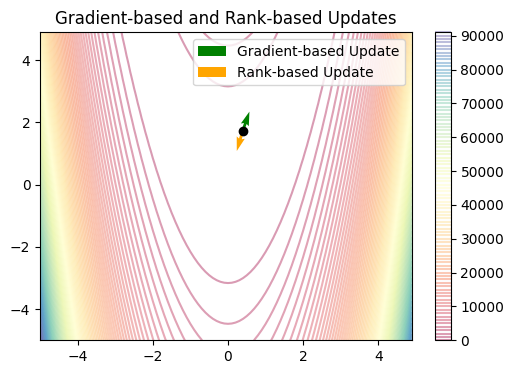

In [75]:
fig = plt.figure(figsize=(6, 4))
cs = plt.contour(X, Y, Z, levels=100, cmap='Spectral', alpha=0.4, norm=norm)
plt.quiver(x[0], x[1], G[0], G[1], color = 'green', label = 'Gradient-based Update')
plt.quiver(x[0], x[1], step_rank[0], step_rank[1], color = 'orange', label = 'Rank-based Update')
plt.scatter(x[0], x[1], c='k')
fig.colorbar(cs)
plt.title('Gradient-based and Rank-based Updates')
plt.legend()
plt.show()

After running both update rules many times, the direction of the rank-based update seems more consistnet and points more reliably towards the global optimum. While the gradient-based update looks more random in each run and the direction varies more. We can also see that the lengths of the update vectors are similar, so updats of similar size.